In [1]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Generate 30 rows of data
data = {
    'Date': pd.date_range(start='2025-11-01', periods=30, freq='D'),
    'Team': np.random.choice(['Backend', 'Frontend', 'DevOps'], 30),
    'Lines_of_Code': np.random.randint(50, 600, 30),
    'Num_of_Bugs_Found': np.random.randint(0, 12, 30),
    'Stress_Level': np.random.choice(['Low', 'Medium', 'High'], 30)
}

df = pd.DataFrame(data)
df.head()

,Date,Team,Lines_of_Code,Num_of_Bugs_Found,Stress_Level
0,2025-11-01,DevOps,525,9,High
1,2025-11-02,Backend,239,3,High
2,2025-11-03,DevOps,293,7,Low
3,2025-11-04,DevOps,554,6,High
4,2025-11-05,Backend,180,11,Low


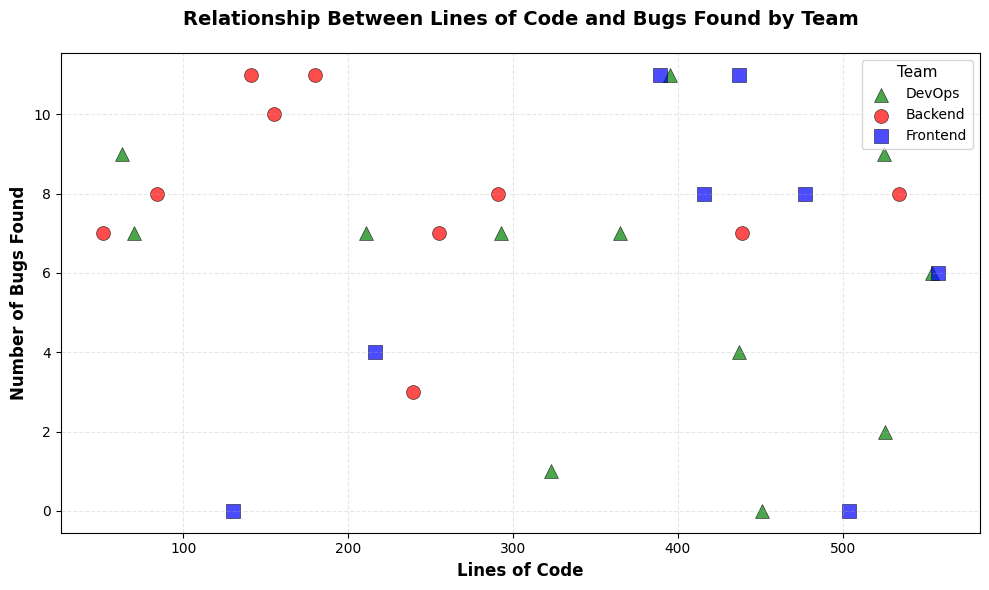

In [2]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Backend': 'red', 'Frontend': 'blue', 'DevOps': 'green'}
markers = {'Backend': 'o', 'Frontend': 's', 'DevOps': '^'}

for team in df['Team'].unique():
    team_data = df[df['Team'] == team]
    ax.scatter(team_data['Lines_of_Code'], 
               team_data['Num_of_Bugs_Found'],
               c=colors[team], marker=markers[team], s=100, alpha=0.7,
               label=team, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Lines of Code', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Bugs Found', fontsize=12, fontweight='bold')
ax.set_title('Relationship Between Lines of Code and Bugs Found by Team', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(title='Team', fontsize=10, title_fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

## Insights from the Visualization

**1. No Clear Linear Correlation:** The scatter plot reveals no strong positive correlation between lines of code and bugs found across all teams. Data points are widely dispersed, suggesting that code volume alone doesn't reliably predict bug count in this dataset.

**2. Team-Specific Patterns:** All teams show similar ranges of bugs (0-12), and the distribution appears relatively uniform regardless of whether developers wrote 50 or 600 lines, indicating other factors beyond code quantity may influence bug detection rates.

In [8]:
results = {
    'Q1: I think that I would like to use this system frequently.': 
        [4, 5, 4, 3, 5, 2, 4, 5, 5, 3, 4, 5],
    
    'Q2: I found the system unnecessarily complex.': 
        [2, 1, 2, 4, 2, 1, 3, 2, 1, 5, 2, 1],
    
    'Q3: I thought the system was easy to use.': 
        [5, 4, 5, 3, 5, 4, 5, 2, 5, 4, 5, 1],
    
    'Q4: I think that I would need the support of a technical person to be able to use this system.': 
        [1, 2, 1, 5, 1, 2, 1, 3, 1, 4, 2, 1],
    
    'Q5: I found the various functions in this system were well integrated.': 
        [4, 3, 4, 2, 5, 4, 3, 5, 4, 2, 5, 5],
    
    'Q6: I thought there was too much inconsistency in this system.': 
        [2, 3, 1, 5, 2, 4, 2, 1, 3, 2, 1, 2],

    'Q7: I would imagine that most people would learn to use this system very quickly.': 
        [5, 4, 5, 3, 4, 5, 4, 2, 5, 4, 5, 3],
    
    'Q8: I found the system very cumbersome to use.': 
        [1, 2, 1, 4, 2, 1, 2, 3, 1, 5, 2, 1],
    
    'Q9: I felt very confident using the system.': 
        [4, 5, 4, 3, 5, 4, 3, 5, 4, 2, 5, 4],
    
    'Q10: I needed to learn a lot of things before I could get going with this system.': 
        [2, 1, 2, 3, 1, 2, 1, 4, 2, 1, 2, 1]
}

In [17]:
sus_labels = {'Q' + str(i): label for i, label in enumerate(results.keys(), start=1)}
sus_counts = {}

for i, (_, scores) in enumerate(results.items(), start=1):
    q_key = f"Q{i}"
    counts = pd.Series(scores).value_counts().sort_index()
    sus_counts[q_key] = {int(rating): int(count) for rating, count in counts.items()}

sus_counts

{'Q1': {2: 1, 3: 2, 4: 4, 5: 5},
 'Q2': {1: 4, 2: 5, 3: 1, 4: 1, 5: 1},
 'Q3': {1: 1, 2: 1, 3: 1, 4: 3, 5: 6},
 'Q4': {1: 6, 2: 3, 3: 1, 4: 1, 5: 1},
 'Q5': {2: 2, 3: 2, 4: 4, 5: 4},
 'Q6': {1: 3, 2: 5, 3: 2, 4: 1, 5: 1},
 'Q7': {2: 1, 3: 2, 4: 4, 5: 5},
 'Q8': {1: 5, 2: 4, 3: 1, 4: 1, 5: 1},
 'Q9': {2: 1, 3: 2, 4: 5, 5: 4},
 'Q10': {1: 5, 2: 5, 3: 1, 4: 1}}

In [18]:
sus_labels

{'Q1': 'Q1: I think that I would like to use this system frequently.',
 'Q2': 'Q2: I found the system unnecessarily complex.',
 'Q3': 'Q3: I thought the system was easy to use.',
 'Q4': 'Q4: I think that I would need the support of a technical person to be able to use this system.',
 'Q5': 'Q5: I found the various functions in this system were well integrated.',
 'Q6': 'Q6: I thought there was too much inconsistency in this system.',
 'Q7': 'Q7: I would imagine that most people would learn to use this system very quickly.',
 'Q8': 'Q8: I found the system very cumbersome to use.',
 'Q9': 'Q9: I felt very confident using the system.',
 'Q10': 'Q10: I needed to learn a lot of things before I could get going with this system.'}

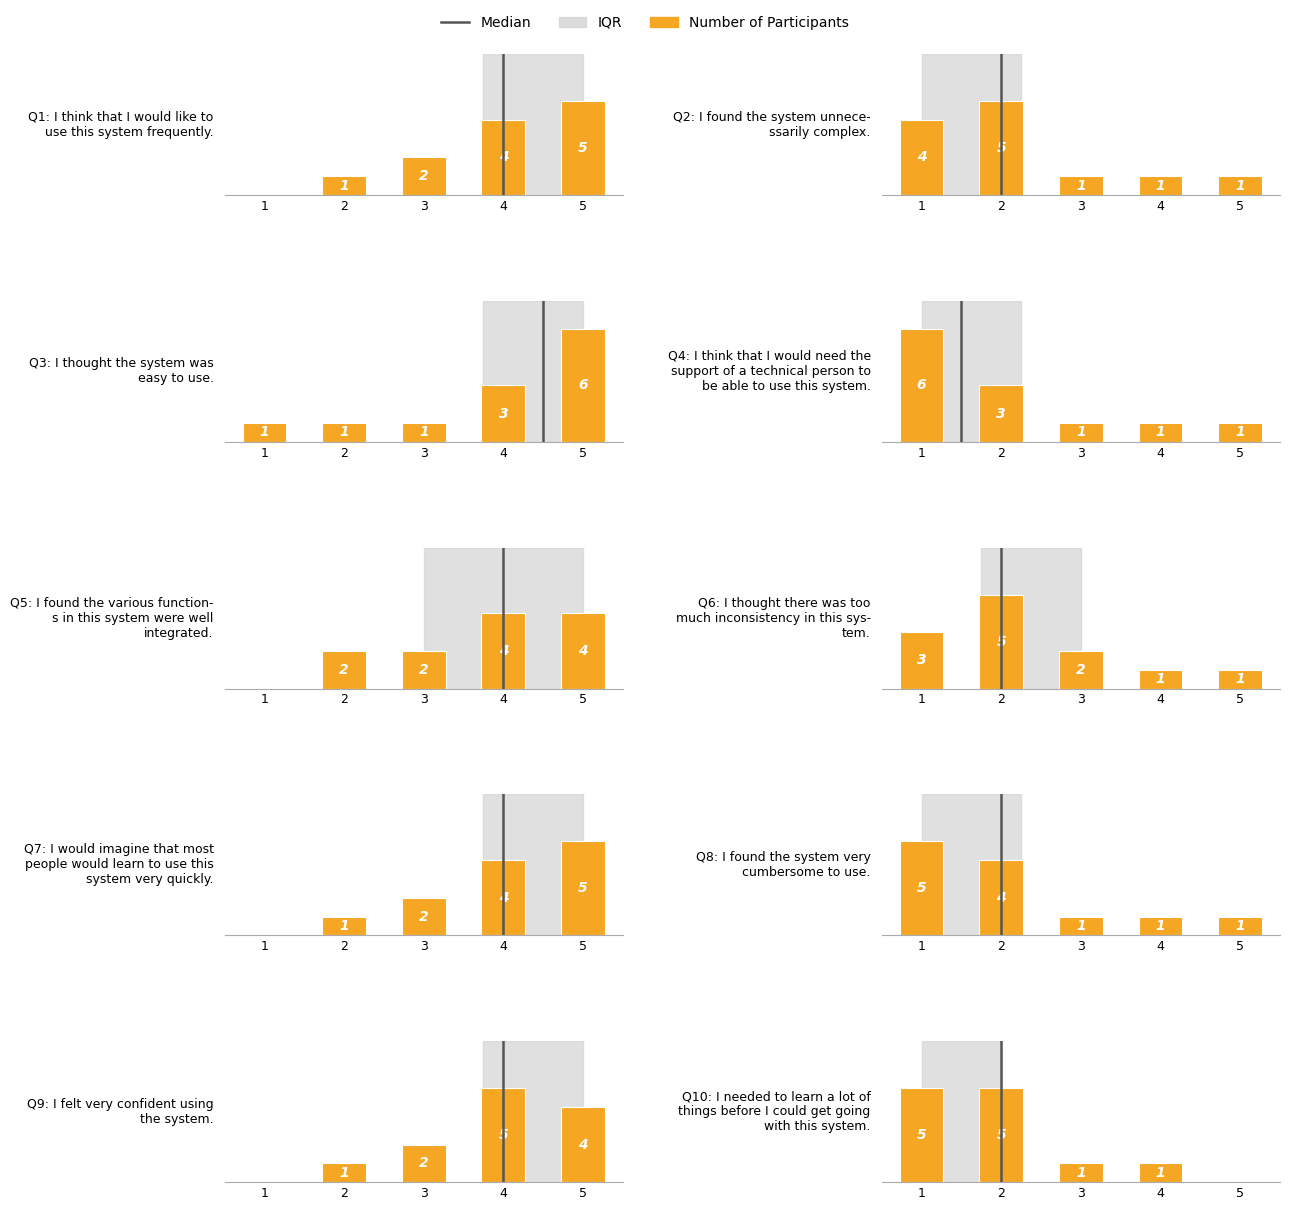

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter

ORANGE  = '#F5A623'
IQR_CLR = '#D3D3D3'
MED_CLR = '#555555'
BAR_W   = 0.55
MAX_H   = 0.80

MAX_COUNT = max(max(Counter(v).values()) for v in results.values())

# Wrapped labels keyed by 'Q1'..'Q10'
wrapped_labels = {
    'Q1':  'Q1: I think that I would like to\nuse this system frequently.',
    'Q2':  'Q2: I found the system unnece-\nssarily complex.',
    'Q3':  'Q3: I thought the system was\neasy to use.',
    'Q4':  'Q4: I think that I would need the\nsupport of a technical person to\nbe able to use this system.',
    'Q5':  'Q5: I found the various function-\ns in this system were well\nintegrated.',
    'Q6':  'Q6: I thought there was too\nmuch inconsistency in this sys-\ntem.',
    'Q7':  'Q7: I would imagine that most\npeople would learn to use this\nsystem very quickly.',
    'Q8':  'Q8: I found the system very\ncumbersome to use.',
    'Q9':  'Q9: I felt very confident using\nthe system.',
    'Q10': 'Q10: I needed to learn a lot of\nthings before I could get going\nwith this system.',
}

q_keys = list(results.keys())
fig, axes = plt.subplots(5, 2, figsize=(13, 12))

for idx, q in enumerate(q_keys):
    row, col = divmod(idx, 2)
    ax = axes[row][col]
    q_id = f'Q{idx + 1}'

    scores   = results[q]
    cnt      = Counter(scores)
    sorted_s = sorted(scores)
    median   = np.median(sorted_s)
    q1_val   = np.percentile(sorted_s, 25)
    q3_val   = np.percentile(sorted_s, 75)

    ax.set_ylim(0, 1)
    ax.set_xlim(0.5, 5.5)

    # ── IQR shaded band ───────────────────────────────────────────────────────
    ax.axvspan(q1_val, q3_val, ymin=0, ymax=1,
               color=IQR_CLR, alpha=0.7, zorder=1)

    # ── Bars: height ∝ count ──────────────────────────────────────────────────
    for rating in range(1, 6):
        count = cnt.get(rating, 0)
        if count == 0:
            continue
        bar_h = (count / MAX_COUNT) * MAX_H
        ax.bar(rating, bar_h, width=BAR_W, bottom=0,
               color=ORANGE, edgecolor='white', linewidth=0.8, zorder=2)
        ax.text(rating, bar_h / 2, str(count),
                ha='center', va='center',
                fontsize=10, fontstyle='italic',
                fontweight='bold', color='white', zorder=3)

    # ── Median line ───────────────────────────────────────────────────────────
    ax.axvline(median, color=MED_CLR, linewidth=1.8, zorder=4)

    # ── Axes ──────────────────────────────────────────────────────────────────
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=9)
    ax.xaxis.set_tick_params(length=0)
    ax.set_yticks([])
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#AAAAAA')
    ax.spines['bottom'].set_linewidth(0.8)

    ax.set_ylabel(wrapped_labels[q_id], fontsize=9, labelpad=8,
                  rotation=0, ha='right', va='center',
                  multialignment='right')

# ── Shared legend ─────────────────────────────────────────────────────────────
med_handle = plt.Line2D([0], [0], color=MED_CLR, linewidth=1.8, label='Median')
iqr_handle = mpatches.Patch(color=IQR_CLR, alpha=0.8, label='IQR')
cnt_handle = mpatches.Patch(color=ORANGE, label='Number of Participants')

fig.legend(handles=[med_handle, iqr_handle, cnt_handle],
           loc='upper center', ncol=3, fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, 1.01))

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.75, wspace=0.65)
plt.savefig('sus_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## Enhancement Proposal

**Colour-code bars by SUS question polarity.** SUS alternates between positively-worded (Q1, Q3, Q5, Q7, Q9 — shown in blue) and negatively-worded (Q2, Q4, Q6, Q8, Q10 — shown in coral) items. This colour distinction acts as a pre-attentive cue, allowing readers of a research paper to instantly identify question polarity and compare response patterns across all 10 questions without re-reading each question's wording.

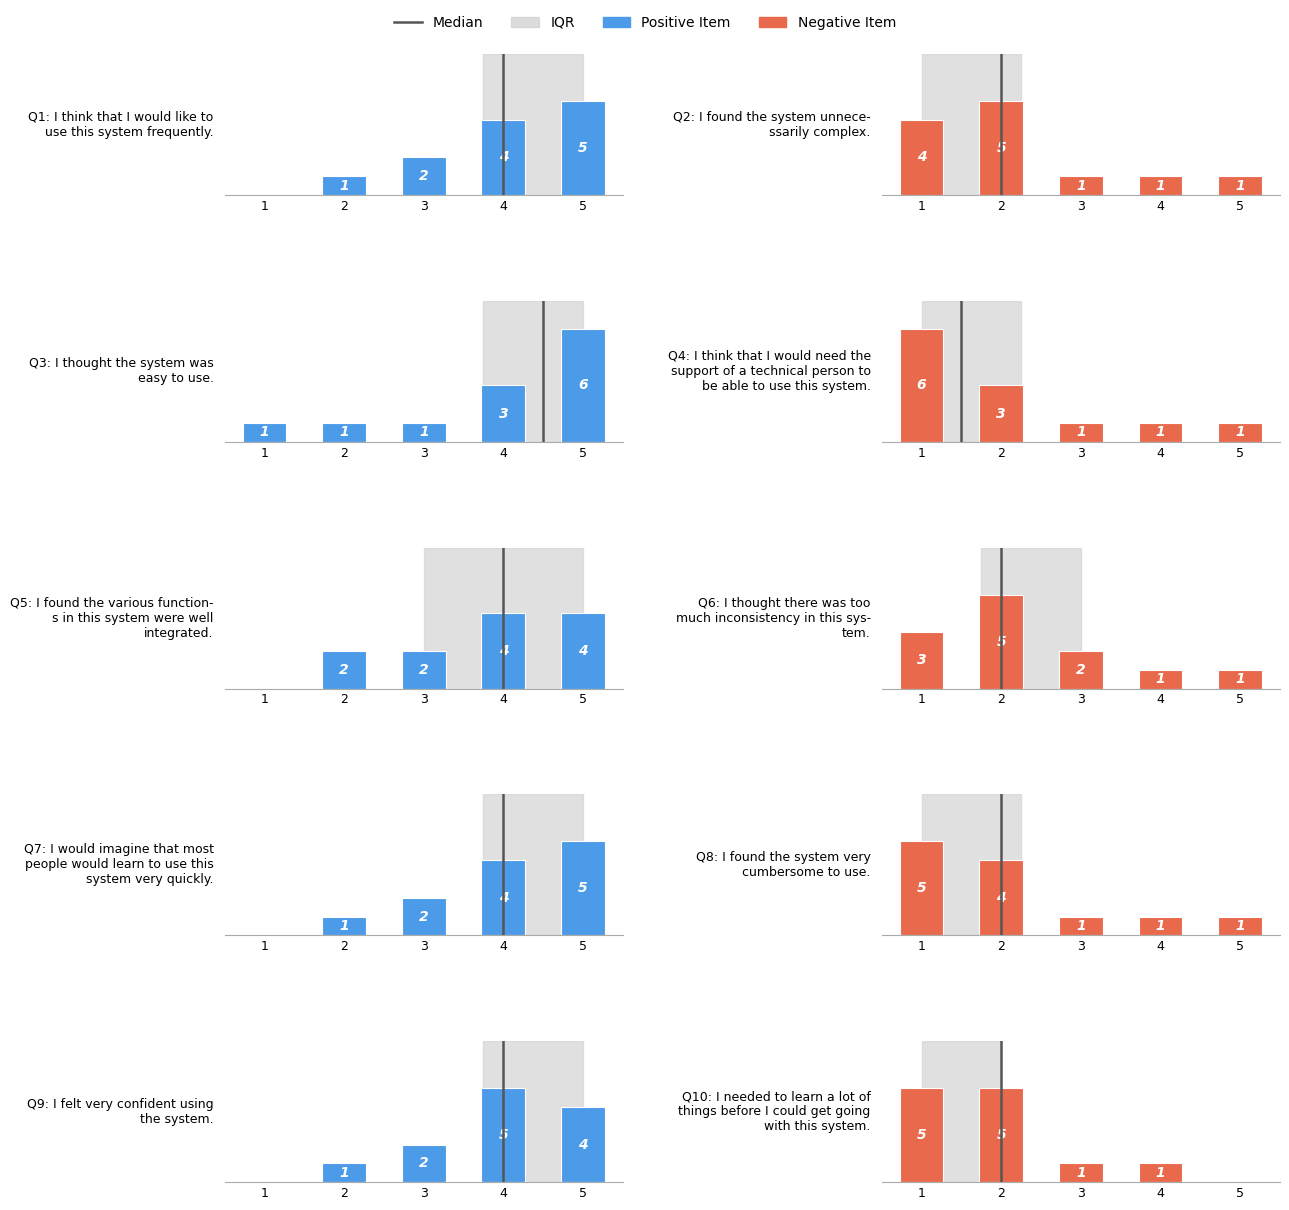

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter

# Positive (odd) and negative (even) SUS questions
POS_COLOR = '#4C9BE8'   # teal-blue  — positive items
NEG_COLOR = '#E8694C'   # coral-red  — negative items
IQR_CLR   = '#D3D3D3'
MED_CLR   = '#555555'

POSITIVE_Q = {'Q1', 'Q3', 'Q5', 'Q7', 'Q9'}   # positive-polarity questions

BAR_W     = 0.55
MAX_H     = 0.80
MAX_COUNT = max(max(Counter(v).values()) for v in results.values())

# Wrapped labels keyed by 'Q1'..'Q10'
wrapped_labels = {
    'Q1':  'Q1: I think that I would like to\nuse this system frequently.',
    'Q2':  'Q2: I found the system unnece-\nssarily complex.',
    'Q3':  'Q3: I thought the system was\neasy to use.',
    'Q4':  'Q4: I think that I would need the\nsupport of a technical person to\nbe able to use this system.',
    'Q5':  'Q5: I found the various function-\ns in this system were well\nintegrated.',
    'Q6':  'Q6: I thought there was too\nmuch inconsistency in this sys-\ntem.',
    'Q7':  'Q7: I would imagine that most\npeople would learn to use this\nsystem very quickly.',
    'Q8':  'Q8: I found the system very\ncumbersome to use.',
    'Q9':  'Q9: I felt very confident using\nthe system.',
    'Q10': 'Q10: I needed to learn a lot of\nthings before I could get going\nwith this system.',
}

q_keys = list(results.keys())
fig, axes = plt.subplots(5, 2, figsize=(13, 12))

for idx, q in enumerate(q_keys):
    row, col = divmod(idx, 2)
    ax = axes[row][col]
    q_num   = f'Q{idx + 1}'
    bar_clr = POS_COLOR if q_num in POSITIVE_Q else NEG_COLOR

    scores   = results[q]
    cnt      = Counter(scores)
    sorted_s = sorted(scores)
    median   = np.median(sorted_s)
    q1_val   = np.percentile(sorted_s, 25)
    q3_val   = np.percentile(sorted_s, 75)

    ax.set_ylim(0, 1)
    ax.set_xlim(0.5, 5.5)

    # ── IQR shaded band ───────────────────────────────────────────────────────
    ax.axvspan(q1_val, q3_val, ymin=0, ymax=1,
               color=IQR_CLR, alpha=0.7, zorder=1)

    # ── Bars: height ∝ count, colour by polarity ──────────────────────────────
    for rating in range(1, 6):
        count = cnt.get(rating, 0)
        if count == 0:
            continue
        bar_h = (count / MAX_COUNT) * MAX_H
        ax.bar(rating, bar_h, width=BAR_W, bottom=0,
               color=bar_clr, edgecolor='white', linewidth=0.8, zorder=2)
        ax.text(rating, bar_h / 2, str(count),
                ha='center', va='center',
                fontsize=10, fontstyle='italic',
                fontweight='bold', color='white', zorder=3)

    # ── Median line ───────────────────────────────────────────────────────────
    ax.axvline(median, color=MED_CLR, linewidth=1.8, zorder=4)

    # ── Axes ──────────────────────────────────────────────────────────────────
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=9)
    ax.xaxis.set_tick_params(length=0)
    ax.set_yticks([])
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#AAAAAA')
    ax.spines['bottom'].set_linewidth(0.8)

    ax.set_ylabel(wrapped_labels[q_num], fontsize=9, labelpad=8,
                  rotation=0, ha='right', va='center',
                  multialignment='right')

# ── Shared legend ─────────────────────────────────────────────────────────────
med_handle = plt.Line2D([0], [0], color=MED_CLR, linewidth=1.8, label='Median')
iqr_handle = mpatches.Patch(color=IQR_CLR, alpha=0.8, label='IQR')
pos_handle = mpatches.Patch(color=POS_COLOR, label='Positive Item')
neg_handle = mpatches.Patch(color=NEG_COLOR, label='Negative Item')

fig.legend(handles=[med_handle, iqr_handle, pos_handle, neg_handle],
           loc='upper center', ncol=4, fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, 1.01))

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.75, wspace=0.65)
plt.savefig('sus_chart_enhanced.png', dpi=150, bbox_inches='tight')
plt.show()

## Reflection: Jupyter Notebooks vs. Script-Based IDEs

**Readability:** Jupyter's Markdown cells encourage rich, structured documentation with headings, equations, and inline visuals that sit directly beside the code they describe. In a `.py` file, documentation is limited to inline comments and docstrings, which are easy to overlook and cannot render formatted output. Notebooks make the intent and result of each step immediately visible, which is especially valuable when presenting an analysis to a non-technical audience.

**Debugging:** The cell-based execution model is a double-edged sword. Isolating a single cell to test a transformation is faster than re-running an entire script. However, variables modified in one cell silently affect later cells, and out-of-order execution can produce bugs that are hard to reproduce, which is a problem non-existent in a top-to-bottom `.py` script with a single execution context.

**Preference:** While I prefer notebooks for data analysis due to ease of use, I tend to opt for standard IDEs when working on software engineering projects. Production code requires version control, modular design, unit testing, which are workflows that `.py` files, packages, and tools like `pytest` support natively. I find notebooks excellent for exploratory data analysis, but their non-linear execution makes them unsuitable for maintaining a large, collaborative codebase.

## Jupyter Extension: Plotly (plotly.py)

🔗 **Tool:** [plotly.py](https://github.com/plotly/plotly.py) — an open-source, interactive, browser-based graphing library for Python with over 18,000 GitHub stars and used by 459,000+ projects.

**1. Aim:** Matplotlib produces static images, which are adequate for print but frustrating during exploration — you cannot pan, zoom, or hover to inspect individual data points. `plotly.py` solves this by rendering fully interactive charts directly inside Jupyter notebooks using a JavaScript engine (plotly.js), with no extra configuration required.

**2. Feature:** The `plotly.express` high-level API is particularly impressive — a single function call like `px.scatter(..., hover_data=[...])` produces a fully interactive chart with tooltips, zoom, and legend toggling. I find this powerful because it compresses what would be dozens of Matplotlib lines into one, while producing a more capable output.

**3. Utility:** A Data Scientist would install this to make exploratory analysis faster and presentations more engaging. Interactive hover tooltips let you instantly identify outliers by name, zoom into dense clusters, and share self-contained HTML charts with stakeholders — all without writing a single line of JavaScript.

## Interactivity and Seaborn

The static Matplotlib scatter plot from earlier is useful, but limited for exploratory analysis. Below we enhance the visualisation in two ways:

1. **Seaborn** — redraws the scatter plot with a built-in regression trend line per team, revealing linear relationships that are invisible in a plain scatter chart.
2. **ipywidgets** — adds a `Lines_of_Code` range slider so you can dynamically filter the data and observe how the bug distribution changes for different code-size windows.

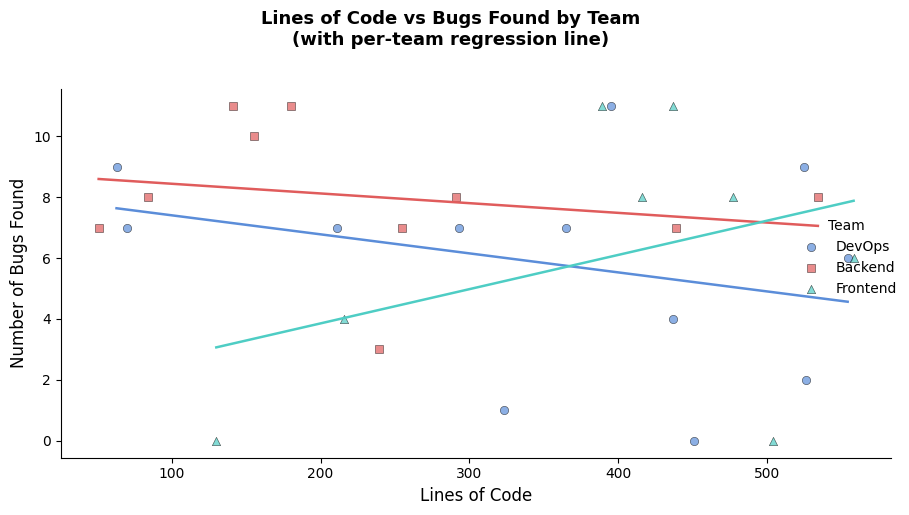

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn lmplot: scatter + per-team OLS regression line
g = sns.lmplot(
    data=df,
    x='Lines_of_Code',
    y='Num_of_Bugs_Found',
    hue='Team',
    palette={'Backend': '#E05C5C', 'Frontend': '#4ECDC4', 'DevOps': '#5B8DD9'},
    markers=['o', 's', '^'],
    height=5,
    aspect=1.6,
    scatter_kws={'alpha': 0.7, 'edgecolors': 'black', 'linewidths': 0.4},
    line_kws={'linewidth': 1.8},
    ci=None,          # suppress confidence-interval band for clarity
)

g.set_axis_labels('Lines of Code', 'Number of Bugs Found', fontsize=12)
g.figure.suptitle(
    'Lines of Code vs Bugs Found by Team\n(with per-team regression line)',
    fontsize=13, fontweight='bold', y=1.02
)
g.legend.set_title('Team')
plt.tight_layout()
plt.show()

In [26]:
import ipywidgets as widgets
from IPython.display import display

colors  = {'Backend': '#E05C5C', 'Frontend': '#4ECDC4', 'DevOps': '#5B8DD9'}
markers = {'Backend': 'o', 'Frontend': 's', 'DevOps': '^'}

loc_slider = widgets.IntRangeSlider(
    value=[df['Lines_of_Code'].min(), df['Lines_of_Code'].max()],
    min=df['Lines_of_Code'].min(),
    max=df['Lines_of_Code'].max(),
    step=10,
    description='LoC range:',
    continuous_update=False,
    layout=widgets.Layout(width='60%'),
    style={'description_width': '80px'},
)

def plot_filtered(loc_range):
    lo, hi = loc_range
    filtered = df[(df['Lines_of_Code'] >= lo) & (df['Lines_of_Code'] <= hi)]

    fig, ax = plt.subplots(figsize=(9, 5))
    for team, grp in filtered.groupby('Team'):
        ax.scatter(grp['Lines_of_Code'], grp['Num_of_Bugs_Found'],
                   c=colors[team], marker=markers[team],
                   s=100, alpha=0.75, label=team,
                   edgecolors='black', linewidths=0.4)

    ax.set_xlabel('Lines of Code', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of Bugs Found', fontsize=11, fontweight='bold')
    ax.set_title(
        f'Bugs vs Lines of Code  |  LoC filter: {lo}–{hi}  '
        f'({len(filtered)} of {len(df)} rows)',
        fontsize=12, fontweight='bold'
    )
    ax.legend(title='Team')
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(plot_filtered, {'loc_range': loc_slider})
display(widgets.VBox([loc_slider, out]))